In [119]:
%%bash

pip install numpy pandas matplotlib scikit-learn xgboost seaborn -q


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

In [ ]:
df_2020 = pd.read_csv('data/df_2020_mit_labels.csv')
df_2021 = pd.read_csv('data/df_2021_mit_labels.csv')

In [3]:
df_2020.shape, df_2021.shape

((466548, 22), (466548, 22))

In [123]:
df_2020 = df_2020.drop(columns=['system:index', 'image_count', '.geo'])
df_2020 = df_2020.fillna(df_2020.mean())

df_2021 = df_2021.drop(columns=['system:index', 'image_count', '.geo'])
df_2021 = df_2021.fillna(df_2021.mean())

In [ ]:
"""
target columns=[
 'bare_sparse_vegetation',
 'built_up',
 'cropland',
 'grassland',
 'herbaceous_wetland',
 'mangroves',
 'moss_lichen',
 'shrubland',
 'snow_ice',
 'tree_cover',
 'water'
 ]

 Change columns in X_train, y_train, X_test, y_test according to the problem statement.
"""
X_train = df_2020.drop(columns=[
 'bare_sparse_vegetation',
 'built_up',
 'cropland',
 'grassland',
 'herbaceous_wetland',
 'mangroves',
 'moss_lichen',
 'shrubland',
 'snow_ice',
 'tree_cover',
 'water'
 ])
y_train = df_2020['tree_cover']

X_test = df_2021.drop(columns=[
 'bare_sparse_vegetation',
 'built_up',
 'cropland',
 'grassland',
 'herbaceous_wetland',
 'mangroves',
 'moss_lichen',
 'shrubland',
 'snow_ice',
 'tree_cover',
 'water'
 ])
y_test = df_2021['tree_cover']

In [125]:
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import root_mean_squared_error, r2_score

In [126]:
def evaluate_regression_model(model_name, model, X_train, X_test, y_train, y_test):
    """
    Fits a model and returns RMSE and R2 for both training and testing sets.
    """
    # 1. Train the model
    model.fit(X_train, y_train)

    # 2. Get predictions for both sets
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    # 3. Calculate Training Metrics
    train_rmse = root_mean_squared_error(y_train, y_train_pred)
    train_r2 = r2_score(y_train, y_train_pred)

    # 4. Calculate Test Metrics
    test_rmse = root_mean_squared_error(y_test, y_test_pred)
    test_r2 = r2_score(y_test, y_test_pred)

    # 5. Print a quick summary
    # model_name = type(model).__name__
    print(f"--- {model_name} ---")
    print(f"Train R2: {train_r2:.4f} | Test R2: {test_r2:.4f}")
    print(f"Train RMSE: {train_rmse:.4f} | Test RMSE: {test_rmse:.4f}\n")

    # 6. Return a dictionary with all 4 metrics
    return {
        'Model': model_name,
        'Train RMSE': train_rmse,
        'Test RMSE': test_rmse,
        'Train R2': train_r2,
        'Test R2': test_r2
    }

In [127]:
models = {
    "Linear Regression": Pipeline([("scaler", StandardScaler()), ("lr", LinearRegression())]),
    "Ridge Regression": Pipeline([("scaler", StandardScaler()), ("ridge", Ridge(alpha=1.0))]),
    "Lasso Regression": Pipeline([("scaler", StandardScaler()), ("lasso", Lasso(alpha=0.1, max_iter=10000))]),
    "SVR": Pipeline([("scaler", StandardScaler()), ("svr", SVR(kernel='rbf', C=100, epsilon=0.1))]),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42, max_depth=10),
    "XGBoost": XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
}

In [128]:
# Execute the loop exactly as before
results = []
for name, model in models.items():
    res = evaluate_regression_model(name, model, X_train, X_test, y_train, y_test)
    results.append(res)

--- Linear Regression ---
Train R2: 0.7916 | Test R2: 0.4691
Train RMSE: 0.1662 | Test RMSE: 0.2678

--- Ridge Regression ---
Train R2: 0.7908 | Test R2: 0.5051
Train RMSE: 0.1666 | Test RMSE: 0.2585

--- Lasso Regression ---
Train R2: 0.5200 | Test R2: 0.4350
Train RMSE: 0.2523 | Test RMSE: 0.2762

--- SVR ---
Train R2: 0.9593 | Test R2: 0.7525
Train RMSE: 0.0735 | Test RMSE: 0.1828

--- Random Forest ---
Train R2: 0.9617 | Test R2: 0.6263
Train RMSE: 0.0712 | Test RMSE: 0.2246

--- XGBoost ---
Train R2: 0.9750 | Test R2: 0.6402
Train RMSE: 0.0576 | Test RMSE: 0.2204



In [129]:
summary_df = pd.DataFrame(results).sort_values(by='Test R2', ascending=False)
summary_df

,Model,Train RMSE,Test RMSE,Train R2,Test R2
3,SVR,0.073451,0.182821,0.959327,0.752485
5,XGBoost,0.057635,0.220429,0.974957,0.640176
4,Random Forest,0.071229,0.224635,0.961750,0.626315
1,Ridge Regression,0.166565,0.258509,0.790837,0.505116
0,Linear Regression,0.166250,0.267751,0.791627,0.469099
2,Lasso Regression,0.252319,0.276221,0.520024,0.434980


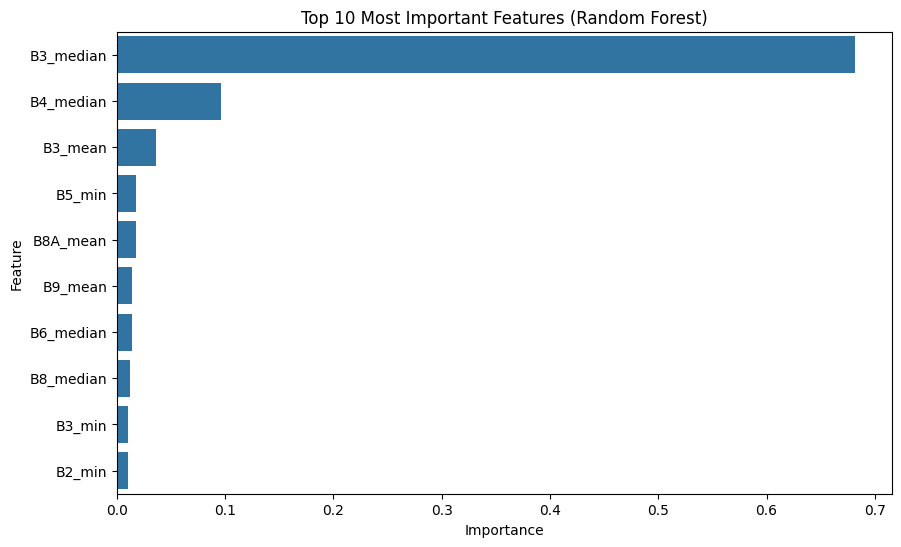

       Feature  Importance
17   B3_median    0.681660
24   B4_median    0.096417
16     B3_mean    0.036266
32      B5_min    0.017821
65    B8A_mean    0.017530
..         ...         ...
94    B4_count    0.000034
102  B8A_count    0.000030
100   B7_count    0.000030
96    B5_count    0.000020
104   B8_count    0.000014

[108 rows x 2 columns]


In [130]:
feature_names = X_train.columns if isinstance(X_train, pd.DataFrame) else [f"Feature {i}" for i in range(X_train.shape[1])]

importances = models['Random Forest'].feature_importances_

feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df.head(10))
plt.title('Top 10 Most Important Features (Random Forest)')
plt.show()

print(feature_importance_df)

In [ ]:
# from sklearn.model_selection import GridSearchCV
# # 1. Define a Pipeline that first scales data then applies SVR
# svr_pipeline = Pipeline([
#     ('scaler', StandardScaler()),
#     ('svr', SVR())
# ])

# # 2. Define the parameter grid including different kernels
# # We test 'rbf' (default), 'linear', 'poly', and 'sigmoid'
# param_grid = {
#     'svr__kernel': ['rbf', 'linear', 'poly', 'sigmoid'],
#     'svr__C': [1, 10, 100],
#     'svr__epsilon': [0.01, 0.1, 0.2],
#     'svr__gamma': ['scale', 'auto'], # gamma is ignored by 'linear'
#     'svr__degree': [2, 3]            # degree is only used by 'poly'
# }

# # 3. Setup GridSearchCV
# print("--- Starting Grid Search for SVR Kernels ---")
# grid_search = GridSearchCV(
#     estimator=svr_pipeline,
#     param_grid=param_grid,
#     cv=5,
#     scoring='r2',
#     n_jobs=-1,
#     verbose=1
# )

# # 4. Fit the grid search using your training data
# grid_search.fit(X_train, y_train)

# # 5. Extract and evaluate the best model
# best_svr_model = grid_search.best_estimator_
# print(f"Best Parameters found: {grid_search.best_params_}")

# # Use your existing evaluation function
# svr_results = evaluate_regression_model(best_svr_model, X_train, X_test, y_train, y_test)

--- Starting Grid Search for SVR Kernels ---
Fitting 5 folds for each of 144 candidates, totalling 720 fits
